# **Import Data and do basic EDA using Pandas Profiling**

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import seaborn as sns
# import pandas_profiling
%matplotlib inline
sns.get_dataset_names()


['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [3]:
titanic = sns.load_dataset('titanic')
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
# Print multiple statements in same line
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [5]:
titanic.shape
titanic.info()
titanic.head()

(891, 15)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [6]:
titanic.isna().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [7]:
titanic.drop(columns = ['who', 'adult_male', 'embark_town', 'alone',
                        'alive', 'class','deck'], inplace = True)

In [8]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [9]:
titanic.isna().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2


In [10]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    object 
 3   age       714 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


In [11]:
titanic[titanic['embarked'].isna()]

,survived,pclass,sex,age,sibsp,parch,fare,embarked
61,1,1,female,38.0,0,0,80.0,NaN
829,1,1,female,62.0,0,0,80.0,NaN


In [12]:
titanic['embarked'].mode()

,embarked
0,S


# **Missing Value Treatment**

In [13]:
# Replacing missing values of a categorical var with mode
titanic['embarked'] = titanic['embarked'].fillna(titanic['embarked'].mode()[0])

In [14]:
titanic.iloc[[61,829],:]

,survived,pclass,sex,age,sibsp,parch,fare,embarked
61,1,1,female,38.0,0,0,80.0,S
829,1,1,female,62.0,0,0,80.0,S


In [15]:
age_missing = titanic[titanic['age'].isna()]
age_missing.sample(10)
age_missing.shape

,survived,pclass,sex,age,sibsp,parch,fare,embarked
773,0,3,male,NaN,0,0,7.2250,C
295,0,1,male,NaN,0,0,27.7208,C
47,1,3,female,NaN,0,0,7.7500,Q
849,1,1,female,NaN,1,0,89.1042,C
87,0,3,male,NaN,0,0,8.0500,S
351,0,1,male,NaN,0,0,35.0000,S
428,0,3,male,NaN,0,0,7.7500,Q
306,1,1,female,NaN,0,0,110.8833,C
680,0,3,female,NaN,0,0,8.1375,Q
601,0,3,male,NaN,0,0,7.8958,S


(177, 8)

In [16]:
titanic['age'].median()


28.0

In [17]:
titanic['age'] = titanic['age'].fillna(titanic['age'].median())
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    object 
 3   age       891 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  891 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


In [18]:
titanic.iloc[[667,368],:]

,survived,pclass,sex,age,sibsp,parch,fare,embarked
667,0,3,male,28.0,0,0,7.775,S
368,1,3,female,28.0,0,0,7.750,Q


In [19]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    object 
 3   age       891 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  891 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


# **Rename the Columns**

In [20]:
titanic = titanic.rename(columns = {"sex":"gender", "SibSp":'siblings', "Parch":"parents_child"})
titanic.head()

,survived,pclass,gender,age,sibsp,parch,fare,embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [21]:
#titanic = titanic.fillna(titanic.median())
#titanic['embarked'] = titanic['embarked'].fillna(titanic['embarked'].mode()[0])

In [22]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   gender    891 non-null    object 
 3   age       891 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  891 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


# **Dummy Coding of Categorical Variables**

In [23]:
# Dummy Coding of Categorical Variables
for x in titanic.columns:
    if titanic[x].dtype == "object":
        titanic[x]=pd.Categorical(titanic[x]).codes

titanic.head()

,survived,pclass,gender,age,sibsp,parch,fare,embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


In [24]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   gender    891 non-null    int8   
 3   age       891 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  891 non-null    int8   
dtypes: float64(2), int64(4), int8(2)
memory usage: 43.6 KB


# **Groupby and Count by the Survival**

In [25]:
titanic.groupby('survived').size()

,0
survived,
0,549
1,342


# **Import Sklearn packages for doing ML modeling**

In [26]:
# Import Sklearn packages for doing ML modeling
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn import tree

# **STEP 1- CREATE FEATURES AND LABEL**

In [27]:
# STEP 1- CREATE FEATURES AND LABEL
x = titanic.drop(['survived'], axis = 1, inplace=False)
y = titanic['survived']
x.shape
print('\n')
y.shape

(891, 7)

(891,)

**STEP 2- SPLIT TRAIN AND TEST DATA**

In [28]:
# STEP 2- SPLIT TRAIN AND TEST DATA
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=999)
x_train.shape
y_train.shape
x_test.shape
y_test.shape

(712, 7)

(712,)

(179, 7)

(179,)

In [29]:
x_train
y_train

,pclass,gender,age,sibsp,parch,fare,embarked
106,3,0,21.0,0,0,7.6500,2
145,2,1,19.0,1,1,36.7500,2
775,3,1,18.0,0,0,7.7500,2
502,3,0,28.0,0,0,7.6292,1
307,1,0,17.0,1,0,108.9000,0
...,...,...,...,...,...,...,...
712,1,1,48.0,1,0,52.0000,2
481,2,1,28.0,0,0,0.0000,2
869,3,1,4.0,1,1,11.1333,2
348,3,1,3.0,1,1,15.9000,2


,survived
106,1
145,0
775,0
502,0
307,1
...,...
712,1
481,0
869,1
348,1


# **Find Survival Rate in both Train and Test Data**

In [30]:
np.round(y_train.sum()/y_train.count()*100,2)
print('\n')
np.round(y_test.sum()/y_test.count()*100,2)

np.float64(39.04)

np.float64(35.75)

# **STEP 3- CREATE INSTANT OF THE MODEL**

In [31]:
# STEP 3- CREATE INSTANT OF THE MODEL
mytree = tree.DecisionTreeClassifier(criterion = 'gini',max_depth = 3,min_samples_leaf = 50,
                                    min_samples_split = 75)
#mytree = tree.DecisionTreeClassifier()

In [32]:
mytree

DecisionTreeClassifier(max_depth=3, min_samples_leaf=50, min_samples_split=75)

In [33]:
mytree

DecisionTreeClassifier(max_depth=3, min_samples_leaf=50, min_samples_split=75)

# **STEP 4- FIT MODEL**

In [34]:
#STEP 4- FIT MODEL
mytree.fit(x_train, y_train)

DecisionTreeClassifier(max_depth=3, min_samples_leaf=50, min_samples_split=75)

# **STEP 5- PREDICT USING THE TRAINED MODEL**

In [35]:
# STEP 5- PREDICT USING THE TRAINED MODEL
predicted = mytree.predict(x_test)
predicted

array([0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0,
       1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 0])

In [36]:
mytree.predict_proba(x_test)

array([[0.61445783, 0.38554217],
       [0.91505792, 0.08494208],
       [0.91505792, 0.08494208],
       [0.91505792, 0.08494208],
       [0.61445783, 0.38554217],
       [0.91505792, 0.08494208],
       [0.32075472, 0.67924528],
       [0.61445783, 0.38554217],
       [0.61428571, 0.38571429],
       [0.61428571, 0.38571429],
       [0.91505792, 0.08494208],
       [0.02469136, 0.97530864],
       [0.91505792, 0.08494208],
       [0.91505792, 0.08494208],
       [0.02469136, 0.97530864],
       [0.61428571, 0.38571429],
       [0.32075472, 0.67924528],
       [0.91505792, 0.08494208],
       [0.61428571, 0.38571429],
       [0.91505792, 0.08494208],
       [0.91505792, 0.08494208],
       [0.76923077, 0.23076923],
       [0.91505792, 0.08494208],
       [0.91505792, 0.08494208],
       [0.61428571, 0.38571429],
       [0.91505792, 0.08494208],
       [0.61445783, 0.38554217],
       [0.91505792, 0.08494208],
       [0.91505792, 0.08494208],
       [0.91505792, 0.08494208],
       [0.

# **STEP 6- EVALUATE MODEL PERFORMANCE**

In [37]:
# STEP 6- EVALUATE MODEL PERFORMANCE
from sklearn import metrics
print(metrics.classification_report(y_test, predicted))

              precision    recall  f1-score   support

           0       0.77      0.99      0.86       115
           1       0.97      0.45      0.62        64

    accuracy                           0.80       179
   macro avg       0.87      0.72      0.74       179
weighted avg       0.84      0.80      0.78       179



In [38]:
mytree

DecisionTreeClassifier(max_depth=3, min_samples_leaf=50, min_samples_split=75)

# **Confusion Matrix Plot using Seaborn**

In [39]:
# Confusion Matrix Plot using Seaborn
df_confusion = metrics.confusion_matrix(y_test,predicted)
df_confusion


array([[114,   1],
       [ 35,  29]])

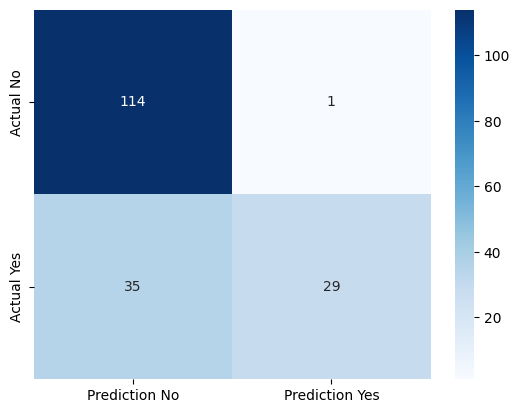

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(df_confusion, cmap = 'Blues',xticklabels=['Prediction No','Prediction Yes'],
            yticklabels=['Actual No','Actual Yes'], annot=True, fmt='d')
plt.show();

# **Classification Accuracy Computation**

In [41]:
# Classification Accuracy Computation
metrics.accuracy_score(y_test, predicted)

0.7988826815642458

In [42]:
# Install graphviz to visualize tree
!pip install graphviz
import graphviz

In [43]:
x.columns

Index(['pclass', 'gender', 'age', 'sibsp', 'parch', 'fare', 'embarked'], dtype='object')

In [44]:
mytree.feature_importances_

array([0.1650994 , 0.71205642, 0.01968967, 0.        , 0.01025265,
       0.05811021, 0.03479166])

In [45]:
y

,survived
0,0
1,1
2,1
3,1
4,0
...,...
886,0
887,1
888,0
889,1


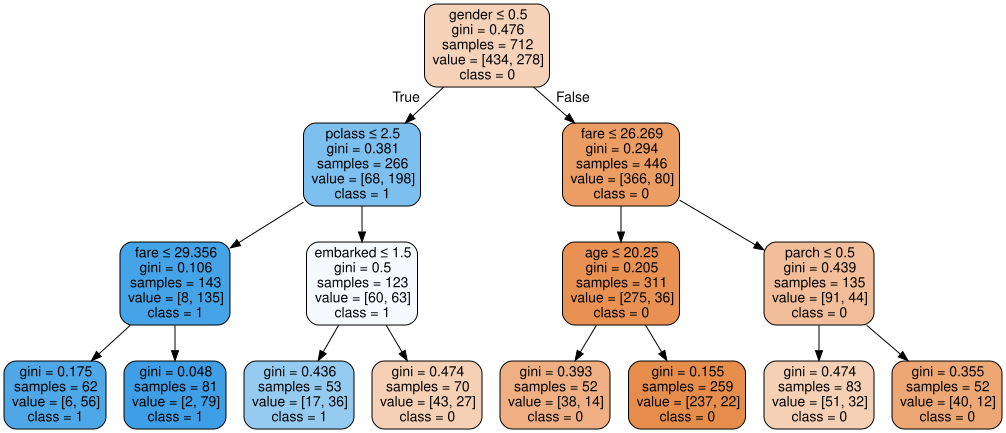

In [46]:
dot_data = tree.export_graphviz(mytree, out_file=None,
                            feature_names=x.columns,
                            class_names= ['0','1'],
                               filled=True, rounded=True,
                               special_characters=True)
graph = graphviz.Source(dot_data)
graph

In [47]:
graph.render('Titanic.png')

'Titanic.png.pdf'

# **Cross-Validation Demo**

In [48]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(mytree, x_train, y_train, cv=5)


In [49]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(mytree, x_train, y_train, cv=5, scoring= 'recall')
scores

array([0.44642857, 0.5       , 0.53571429, 0.63636364, 0.70909091])

# **Hyper-parameters Optimization**

In [50]:
mytree = tree.DecisionTreeClassifier(random_state=99, class_weight= 'balanced')
mytree

DecisionTreeClassifier(class_weight='balanced', random_state=99)

In [51]:
my_max_depth = [2,3,4,5,10] # 5
my_criterion = ['gini', 'entropy'] # 2
my_min_samples_leaf= [2, 5, 10,15,20,25] # 6
my_min_samples_split=[2,5,10, 15, 50,100] # 6

In [52]:
# number of models
len(my_max_depth)*len(my_criterion)*len(my_min_samples_leaf)*len(my_min_samples_split)

360

In [53]:
# Importing GridSearch
from sklearn.model_selection import GridSearchCV
'''
mytree = tree.DecisionTreeClassifier(random_state=99, class_weight= 'balanced')
mytree

'''

"\nmytree = tree.DecisionTreeClassifier(random_state=99, class_weight= 'balanced')\nmytree\n\n"

In [54]:
# Building the model


# Cross-validation tells how well a model performs on a dataset using multiple samples of train data
grid = GridSearchCV(estimator = mytree, cv=5, scoring= 'recall',
                    param_grid = dict(max_depth = my_max_depth, criterion = my_criterion,
                                      min_samples_leaf = my_min_samples_leaf,
                                      min_samples_split= my_min_samples_split))

In [55]:
grid.fit(x_train, y_train)

GridSearchCV(cv=5,
             estimator=DecisionTreeClassifier(class_weight='balanced',
                                              random_state=99),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [2, 3, 4, 5, 10],
                         'min_samples_leaf': [2, 5, 10, 15, 20, 25],
                         'min_samples_split': [2, 5, 10, 15, 50, 100]},
             scoring='recall')

In [56]:
np.round(grid.best_estimator_.feature_importances_,2)
print()
grid.best_estimator_.feature_importances_.sum()
print()
x_train.columns

array([0.18, 0.65, 0.09, 0.  , 0.  , 0.07, 0.02])

np.float64(1.0)

Index(['pclass', 'gender', 'age', 'sibsp', 'parch', 'fare', 'embarked'], dtype='object')

In [57]:
grid.best_params_

{'criterion': 'gini',
 'max_depth': 5,
 'min_samples_leaf': 20,
 'min_samples_split': 50}

In [58]:
grid.best_estimator_.feature_importances_
print()
x.columns

array([0.17766848, 0.64657247, 0.08641906, 0.        , 0.        ,
       0.06719105, 0.02214894])

Index(['pclass', 'gender', 'age', 'sibsp', 'parch', 'fare', 'embarked'], dtype='object')

In [59]:
grid.predict(x_test)

array([0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0,
       1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0,
       1, 0, 0])

In [60]:
np.round(grid.best_score_, 2)*100

np.float64(81.0)

In [61]:
# Best parameters for the model
results = pd.DataFrame(grid.cv_results_)
results.to_csv("results.csv")

In [62]:
pwd()

'/content'

In [63]:
predicted = grid.predict(x_test)
from sklearn import metrics
print(metrics.classification_report(y_test, predicted))

              precision    recall  f1-score   support

           0       0.80      0.88      0.84       115
           1       0.74      0.61      0.67        64

    accuracy                           0.78       179
   macro avg       0.77      0.74      0.75       179
weighted avg       0.78      0.78      0.78       179



In [64]:
predicted

array([0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0,
       1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0,
       1, 0, 0])

# **Predict Probability of the classes**

In [65]:
predicted_prob = grid.predict_proba(x_test)
np.round(predicted_prob,3)

array([[0.742, 0.258],
       [0.889, 0.111],
       [0.889, 0.111],
       [0.889, 0.111],
       [0.408, 0.592],
       [0.742, 0.258],
       [0.314, 0.686],
       [0.742, 0.258],
       [0.456, 0.544],
       [0.852, 0.148],
       [0.889, 0.111],
       [0.   , 1.   ],
       [0.889, 0.111],
       [0.712, 0.288],
       [0.   , 1.   ],
       [0.307, 0.693],
       [0.155, 0.845],
       [0.712, 0.288],
       [0.852, 0.148],
       [0.889, 0.111],
       [0.889, 0.111],
       [0.562, 0.438],
       [0.889, 0.111],
       [0.889, 0.111],
       [0.456, 0.544],
       [0.889, 0.111],
       [0.719, 0.281],
       [0.889, 0.111],
       [0.889, 0.111],
       [0.889, 0.111],
       [0.852, 0.148],
       [0.889, 0.111],
       [0.562, 0.438],
       [0.562, 0.438],
       [0.889, 0.111],
       [0.889, 0.111],
       [0.742, 0.258],
       [0.889, 0.111],
       [0.889, 0.111],
       [0.889, 0.111],
       [0.889, 0.111],
       [0.102, 0.898],
       [0.889, 0.111],
       [0.5

In [66]:
# Find out probability of the classes and predicted classes
predicted_prob = grid.predict_proba(x_test)
predicted_prob_df = pd.DataFrame(predicted_prob)
predicted_classes_df = pd.DataFrame(predicted)
y_actual_df = pd.DataFrame(y_test.values)
predicted_df = pd.concat([predicted_prob_df, predicted_classes_df, y_actual_df], axis=1)
predicted_df.columns = ['Prob_0','Prob_1','Predicted_Class', 'Actual_Class']
predicted_df.sample(20)


,Prob_0,Prob_1,Predicted_Class,Actual_Class
25,0.888578,0.111422,0,0
69,0.888578,0.111422,0,0
159,0.888578,0.111422,0,0
72,0.046959,0.953041,1,1
90,0.888578,0.111422,0,1
10,0.888578,0.111422,0,0
35,0.888578,0.111422,0,0
137,0.455826,0.544174,1,0
23,0.888578,0.111422,0,0
115,0.285891,0.714109,1,0


In [67]:
predicted_prob

array([[0.74243323, 0.25756677],
       [0.88857796, 0.11142204],
       [0.88857796, 0.11142204],
       [0.88857796, 0.11142204],
       [0.4082232 , 0.5917768 ],
       [0.74243323, 0.25756677],
       [0.31391147, 0.68608853],
       [0.74243323, 0.25756677],
       [0.45582562, 0.54417438],
       [0.85217984, 0.14782016],
       [0.88857796, 0.11142204],
       [0.        , 1.        ],
       [0.88857796, 0.11142204],
       [0.71187405, 0.28812595],
       [0.        , 1.        ],
       [0.30722004, 0.69277996],
       [0.15470228, 0.84529772],
       [0.71187405, 0.28812595],
       [0.85217984, 0.14782016],
       [0.88857796, 0.11142204],
       [0.88857796, 0.11142204],
       [0.56161616, 0.43838384],
       [0.88857796, 0.11142204],
       [0.88857796, 0.11142204],
       [0.45582562, 0.54417438],
       [0.88857796, 0.11142204],
       [0.71927555, 0.28072445],
       [0.88857796, 0.11142204],
       [0.88857796, 0.11142204],
       [0.88857796, 0.11142204],
       [0.

# **Thresold Optimization**

In [68]:
predicted_prob =grid.predict_proba(x_test)
predicted_prob


array([[0.74243323, 0.25756677],
       [0.88857796, 0.11142204],
       [0.88857796, 0.11142204],
       [0.88857796, 0.11142204],
       [0.4082232 , 0.5917768 ],
       [0.74243323, 0.25756677],
       [0.31391147, 0.68608853],
       [0.74243323, 0.25756677],
       [0.45582562, 0.54417438],
       [0.85217984, 0.14782016],
       [0.88857796, 0.11142204],
       [0.        , 1.        ],
       [0.88857796, 0.11142204],
       [0.71187405, 0.28812595],
       [0.        , 1.        ],
       [0.30722004, 0.69277996],
       [0.15470228, 0.84529772],
       [0.71187405, 0.28812595],
       [0.85217984, 0.14782016],
       [0.88857796, 0.11142204],
       [0.88857796, 0.11142204],
       [0.56161616, 0.43838384],
       [0.88857796, 0.11142204],
       [0.88857796, 0.11142204],
       [0.45582562, 0.54417438],
       [0.88857796, 0.11142204],
       [0.71927555, 0.28072445],
       [0.88857796, 0.11142204],
       [0.88857796, 0.11142204],
       [0.88857796, 0.11142204],
       [0.

In [69]:
grid.predict(x_test)

array([0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0,
       1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0,
       1, 0, 0])

In [70]:
testcase = np.round(predicted_prob[0], 3)
testcase

array([0.742, 0.258])

In [71]:
predicted_prob[0,1]

np.float64(0.25756676557863495)

In [72]:
testcase_prediction = testcase[1] >= 0.25
testcase_prediction

np.True_

In [73]:
# Apply new thresold for optimizing Precision and Recall
new_y_test = predicted_prob [:,1] >= 0.25

In [74]:
#predicted_prob

In [75]:
predicted_prob

array([[0.74243323, 0.25756677],
       [0.88857796, 0.11142204],
       [0.88857796, 0.11142204],
       [0.88857796, 0.11142204],
       [0.4082232 , 0.5917768 ],
       [0.74243323, 0.25756677],
       [0.31391147, 0.68608853],
       [0.74243323, 0.25756677],
       [0.45582562, 0.54417438],
       [0.85217984, 0.14782016],
       [0.88857796, 0.11142204],
       [0.        , 1.        ],
       [0.88857796, 0.11142204],
       [0.71187405, 0.28812595],
       [0.        , 1.        ],
       [0.30722004, 0.69277996],
       [0.15470228, 0.84529772],
       [0.71187405, 0.28812595],
       [0.85217984, 0.14782016],
       [0.88857796, 0.11142204],
       [0.88857796, 0.11142204],
       [0.56161616, 0.43838384],
       [0.88857796, 0.11142204],
       [0.88857796, 0.11142204],
       [0.45582562, 0.54417438],
       [0.88857796, 0.11142204],
       [0.71927555, 0.28072445],
       [0.88857796, 0.11142204],
       [0.88857796, 0.11142204],
       [0.88857796, 0.11142204],
       [0.

In [76]:
predicted_prob[0,1]

np.float64(0.25756676557863495)

In [77]:
# Apply new thresold for optimizing Precision and Recall
new_y_test = predicted_prob [:,1] >= 0.9

In [78]:
new_y_test

array([False, False, False, False, False, False, False, False, False,
       False, False,  True, False, False,  True, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False,  True, False, False, False,  True, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False,  True, False, False, False, False,
        True, False, False, False,  True, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False,  True, False, False, False,
       False, False, False, False, False, False,  True, False, False,
        True, False,  True, False, False,  True, False, False, False,
        True, False,  True, False,  True, False, False, False, False,
       False,  True,

In [79]:
print(metrics.classification_report(y_test, predicted))

              precision    recall  f1-score   support

           0       0.80      0.88      0.84       115
           1       0.74      0.61      0.67        64

    accuracy                           0.78       179
   macro avg       0.77      0.74      0.75       179
weighted avg       0.78      0.78      0.78       179



In [80]:


print(metrics.classification_report(y_test, new_y_test))

              precision    recall  f1-score   support

           0       0.74      1.00      0.85       115
           1       1.00      0.38      0.55        64

    accuracy                           0.78       179
   macro avg       0.87      0.69      0.70       179
weighted avg       0.83      0.78      0.74       179



# **Random Forest**

In [81]:
my_estimators = [10, 100,1000] #3
my_max_depth = [5,10,15] # 3
my_criterion = ['gini', 'entropy'] # 2
my_min_samples_leaf= [2, 5, 10,15] # 4
my_min_samples_split=[2,5,10] # 3

In [82]:
from sklearn.ensemble import RandomForestClassifier

forest = RandomForestClassifier(class_weight='balanced', random_state= 23)

In [83]:
# Importing GridSearch
from sklearn.model_selection import GridSearchCV

In [84]:
# Start time
import time
start = time.time()




# Building the model


# Cross-validation tells how well a model performs on a dataset using multiple samples of train data
grid_rf = GridSearchCV(estimator = forest, cv=4, scoring= 'recall',
                    param_grid = dict(max_depth = my_max_depth, criterion = my_criterion,
                                      min_samples_leaf = my_min_samples_leaf,
                                      min_samples_split= my_min_samples_split,
                                      n_estimators = my_estimators ))

grid_rf.fit(x,y)


end = time.time()

training_time = end-start
print("Time taken to train Logistic Regression: ", training_time)

KeyboardInterrupt: 

In [ ]:
grid_rf.best_params_

In [ ]:
grid_rf.best_score_

In [ ]:
grid_rf.best_estimator_.feature_importances_
x.columns

In [ ]:
predicted = grid_rf.predict(x_test)
from sklearn import metrics
print(metrics.classification_report(y_test, predicted))

In [ ]:
grid_rf.param_grid

In [ ]:
mytree.feature_importances_

In [ ]:
grid_rf.best_params_

In [ ]:
help(forest)

In [ ]:
help(GridSearchCV)

In [ ]:
help(mytree)